<a href="https://colab.research.google.com/github/Wasim2006-dev/phoneinfoga/blob/master/customer_segmentation_using_ml(k_means_clustering)_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#import data

In [5]:
from google.colab import files
uploaded=files.upload()

Saving customer_segmentation.csv to customer_segmentation.csv


In [7]:
df=pd.read_csv('customer_segmentation.csv')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [9]:
df.shape

(2240, 29)

In [10]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [11]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [23]:
df=df.dropna().copy()

#select features for scalling

In [15]:
x=df[['Income',
        'MntWines',
        'MntFruits',
        'MntMeatProducts',
        'MntFishProducts',
        'MntSweetProducts',
        'MntGoldProds']]



In [16]:
x

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,58138.0,635,88,546,172,88,88
1,46344.0,11,1,6,2,1,6
2,71613.0,426,49,127,111,21,42
3,26646.0,11,4,20,10,3,5
4,58293.0,173,43,118,46,27,15
...,...,...,...,...,...,...,...
2235,61223.0,709,43,182,42,118,247
2236,64014.0,406,0,30,0,0,8
2237,56981.0,908,48,217,32,12,24
2238,69245.0,428,30,214,80,30,61


#feature scalling

In [18]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

#find best k using elbow method

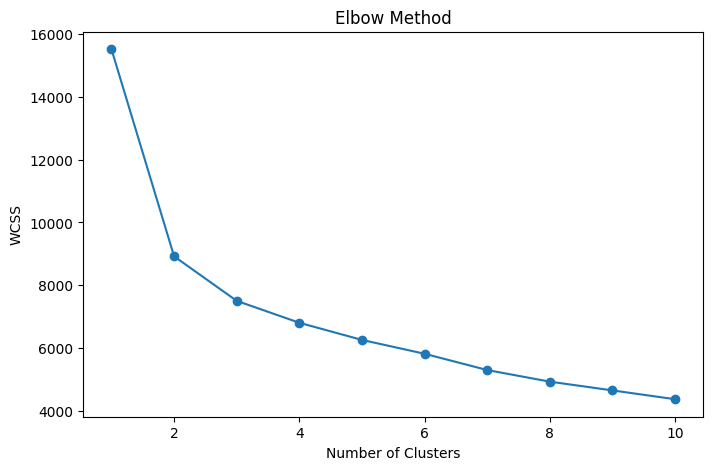

In [20]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

#train kmeans

In [22]:
kmeans = KMeans(n_clusters=4,
                random_state=42,
                n_init=10)

y_pred = kmeans.fit_predict(x_scaled)

df['Cluster'] = y_pred

/tmp/ipykernel_2977/3262727368.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = y_pred


#view cluster counts

In [25]:
df['Cluster'].value_counts()

,count
Cluster,
1,1130
0,501
3,305
2,280


#vizualize clusters

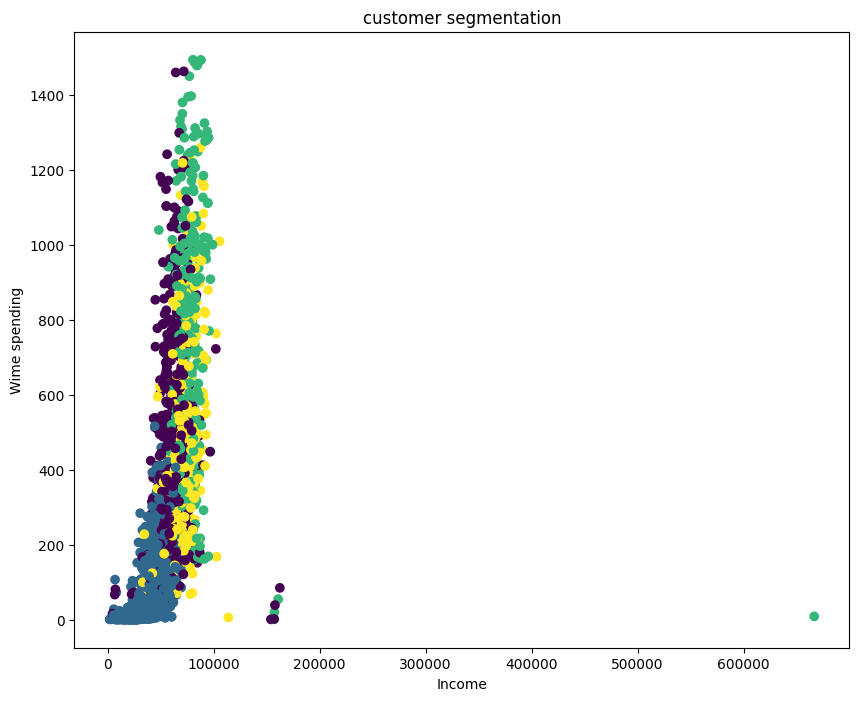

In [26]:
plt.figure(figsize=(10,8))
plt.scatter(df['Income'],
            df['MntWines'],
            c=df['Cluster'],
            cmap='viridis')
plt.xlabel("Income")
plt.ylabel("Wime spending")
plt.title("customer segmentation")
plt.show()


#clusture summary

In [29]:
summary=df.groupby("Cluster")[x.columns].mean()
summary

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,,
0,60773.371257,476.956088,20.762475,143.550898,31.347305,22.075848,72.103792
1,35964.161947,63.386726,5.096460,27.642478,7.275221,5.115044,14.850442
2,80076.442857,772.628571,44.964286,523.107143,70.928571,46.342857,54.950000
3,73021.452459,489.065574,97.226230,394.878689,129.898361,98.622951,95.527869


#error

In [31]:
df['cluster']=y_pred
df['cluster']

,cluster
0,3
1,1
2,0
3,1
4,0
...,...
2235,3
2236,1
2237,0
2238,0


In [33]:
print(df.shape)
print(len(y_pred))

(2216, 31)
2216


In [35]:
X = df[['Income','MntWines','MntFruits','MntMeatProducts',
        'MntFishProducts','MntSweetProducts','MntGoldProds']]

X_scaled = scaler.fit_transform(X)

y_pred = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_pred
df['cluster']

,cluster
0,3
1,1
2,0
3,1
4,0
...,...
2235,3
2236,1
2237,0
2238,0
